# Meteorological context (SPEI) for the three case-study propagation chains

**Purpose.** Response analysis for **Reviewer #2, comment 4** (hydroclimatic context for the case studies) and **Reviewer #4, comment 5** (meteorological-hydrological linkage, addressed here as an initial, illustrative step -- full coupling remains future work, see the tracker response).

**What this does.** For each of the three case studies (Section 3.2, Figs. 6-8), plot the daily SSI at the *origin* station alongside weekly SPEI-3 and SPEI-12 at that station's coordinates, over the same approximate context window used in Figures 6-8.

**Station coordinates** (converted from UTM, ETRS89/UTM 30N, and cross-checked against the known real-world locations):

| Station | Case | Location | Lat | Lon |
|---|---|---|---|---|
| 9027 | 1 (1988-89) | Ebro at Tortosa | 40.81 | 0.52 |
| 9011 | 2 (2016-18) | Ebro at Zaragoza | 41.66 | -0.88 |
| 9005 | 3 (1997) | Arag\u00f3n at Caparroso | 42.35 | -1.65 |

**Important, honest finding (see Section 7 below):** local SPEI at the origin station does *not* show a uniform "meteorological drought precedes hydrological drought" pattern across the three cases -- and this is informative, not a weakness.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
DATA, OUT = "./", "./"
ssi_daily = pd.read_csv(DATA+"SSI_daily.csv", parse_dates=["date"])

## 1. Case definitions
Context windows are approximate (matching Figs. 6-8 by eye); the hydrological event window (grey shading) uses the exact chain start/end dates reported in the manuscript.

In [2]:
CASES = [
    ("Case 1 (1988-1989)\nOrigin: 9027 - Ebro at Tortosa",
     9027, "DATA_40_81_0_52.csv", "1987-06-01", "1989-08-01", "1988-09-21", "1989-04-24"),
    ("Case 2 (2016-2018)\nOrigin: 9011 - Ebro at Zaragoza",
     9011, "DATA_41_66_-0_88.csv", "2015-06-01", "2018-06-01", "2016-12-30", "2018-03-01"),
    ("Case 3 (1997)\nOrigin: 9005 - Aragon at Caparroso",
     9005, "DATA_42_35_-1_65.csv", "1996-06-01", "1997-10-01", "1997-02-28", "1997-05-30"),
]
for label, sid, f, cs, ce, es, ee in CASES:
    print(label.replace("\n"," | "))

Case 1 (1988-1989) | Origin: 9027 - Ebro at Tortosa
Case 2 (2016-2018) | Origin: 9011 - Ebro at Zaragoza
Case 3 (1997) | Origin: 9005 - Aragon at Caparroso


## 2. Sanity check: data coverage in each window (no gaps)

In [3]:
for label, sid, speicsv, ctx_s, ctx_e, ev_s, ev_e in CASES:
    ctx_s2, ctx_e2 = pd.Timestamp(ctx_s), pd.Timestamp(ctx_e)
    ssi = ssi_daily[(ssi_daily.station_id==sid)&(ssi_daily.date>=ctx_s2)&(ssi_daily.date<=ctx_e2)]
    spei = pd.read_csv(DATA+speicsv, parse_dates=["DATA"])
    spei = spei[(spei.DATA>=ctx_s2)&(spei.DATA<=ctx_e2)]
    print(f"{sid}: SSI n={len(ssi)} NaN={ssi.SSI.isna().sum()} | "
          f"SPEI-3 NaN={spei.spei_3.isna().sum()} SPEI-12 NaN={spei.spei_12.isna().sum()}")

9027: SSI n=793 NaN=0 | SPEI-3 NaN=0 SPEI-12 NaN=0
9011: SSI n=1097 NaN=0 | SPEI-3 NaN=0 SPEI-12 NaN=0
9005: SSI n=488 NaN=0 | SPEI-3 NaN=0 SPEI-12 NaN=0


## 3. Origin station's own individual SSI events (within each context window)

**Important correction from an earlier draft:** the "hydrological event" window quoted in the manuscript's Figures 6-8 titles (e.g. "21 September 1988 - 24 April 1989" for Case 1) is the **chain window** -- the earliest onset to the latest termination among *all* matched stations in the chain (Table 2: t(c,s), t(c,e)) -- not the origin station's own individual SSI event. Because upstream stations typically enter drought earlier (negative lag), the chain window can start well before, and this can even span multiple, separate individual events at the origin itself. This is checked explicitly below using the same event-detection algorithm validated in Section S5.

In [4]:
origin_events = pd.read_csv(DATA+"origin_events_full.csv", parse_dates=["start_date","end_date"])
for label, sid, speicsv, ctx_s, ctx_e, ev_s, ev_e in CASES:
    ctx_s2, ctx_e2 = pd.Timestamp(ctx_s), pd.Timestamp(ctx_e)
    own = origin_events[(origin_events.station_id==sid) &
                         (origin_events.start_date<=ctx_e2) & (origin_events.end_date>=ctx_s2)]
    print(label.replace("\n"," | "))
    print(f"  Chain window (Figs. 6-8 title): {ev_s} to {ev_e}")
    print(f"  Origin\'s own event(s) in this window:")
    print("  " + own[["start_date","end_date","duration"]].to_string(index=False).replace("\n","\n  "))
    print()

Case 1 (1988-1989) | Origin: 9027 - Ebro at Tortosa
  Chain window (Figs. 6-8 title): 1988-09-21 to 1989-04-24
  Origin's own event(s) in this window:
  start_date   end_date  duration
  1987-05-13 1987-07-09        58
  1989-01-23 1989-04-24        92
  1989-05-28 1989-07-04        38

Case 2 (2016-2018) | Origin: 9011 - Ebro at Zaragoza
  Chain window (Figs. 6-8 title): 2016-12-30 to 2018-03-01
  Origin's own event(s) in this window:
  start_date   end_date  duration
  2015-12-16 2016-01-04        20
  2016-12-11 2017-01-11        32
  2017-04-11 2017-06-01        52
  2017-06-14 2017-06-25        12
  2017-07-07 2017-08-27        52
  2017-09-08 2017-11-06        60
  2017-11-22 2017-12-02        11

Case 3 (1997) | Origin: 9005 - Aragon at Caparroso
  Chain window (Figs. 6-8 title): 1997-02-28 to 1997-05-30
  Origin's own event(s) in this window:
  start_date   end_date  duration
  1996-06-28 1996-07-02         5
  1997-03-16 1997-04-28        44



**Reading this table:** for Case 1, the origin's own event (1989-01-23 to 1989-04-24) starts *4 months after* the chain window's start -- the earlier part of the chain window reflects upstream stations only. For Case 2, the origin has *six separate, shorter* events within the 427-day chain window, meaning the origin itself recovers (SSI rises above the threshold) several times while the network-wide chain is reported as continuous. For Case 3, the origin's own event (44 days) is narrower than the 92-day chain window on both sides. This directly supports the manuscript's storage-/network-driven framing: the origin station in isolation does not fully capture the network-wide propagation signal.

## 4. Publication figure
Two layers: (i) the **chain window** (grey background, network-wide span as in Figs. 6-8 titles) and (ii) the **origin station's own individual SSI event(s)** (highlighted in red, directly on its SSI curve) -- letting the reader see both explicitly, rather than conflating them.

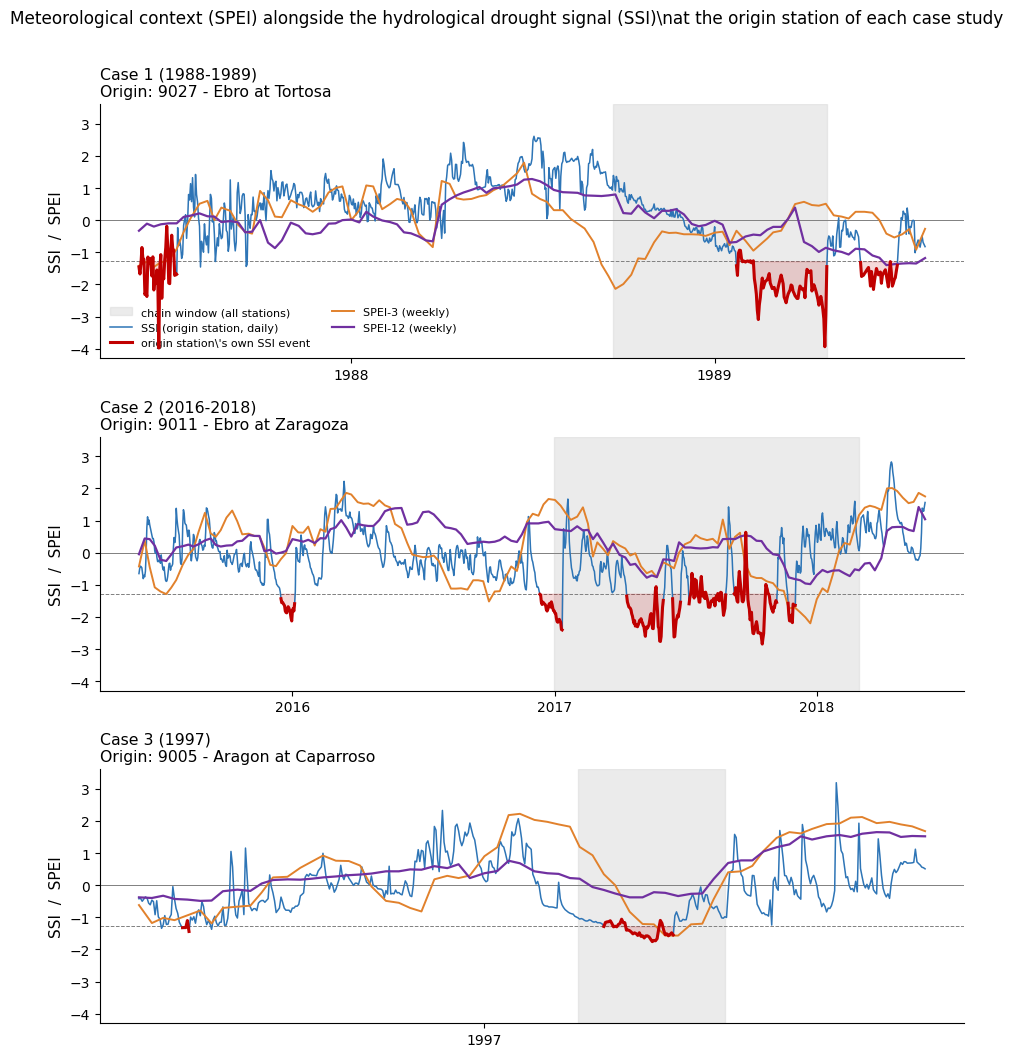

In [5]:
BLUE,ORANGE,PURPLE,GREY,RED = "#2E75B6","#E1812C","#7030A0","#D9D9D9","#C00000"
plt.rcParams.update({"font.size":11.5,"axes.titlesize":11.5,"axes.labelsize":11,
    "xtick.labelsize":10,"ytick.labelsize":10,"font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False})
fig,axes = plt.subplots(3,1,figsize=(9.5,10.5))
for ax,(label,sid,speicsv,ctx_s,ctx_e,ev_s,ev_e) in zip(axes,CASES):
    ctx_s,ctx_e,ev_s,ev_e = map(pd.Timestamp,[ctx_s,ctx_e,ev_s,ev_e])
    ssi = ssi_daily[(ssi_daily.station_id==sid)&(ssi_daily.date>=ctx_s)&(ssi_daily.date<=ctx_e)]
    spei = pd.read_csv(DATA+speicsv, parse_dates=["DATA"])
    spei = spei[(spei.DATA>=ctx_s)&(spei.DATA<=ctx_e)]
    own = origin_events[(origin_events.station_id==sid)&(origin_events.start_date<=ctx_e)&(origin_events.end_date>=ctx_s)]

    ax.axvspan(ev_s,ev_e,color=GREY,alpha=0.5,zorder=0,label="chain window (all stations)")
    ax.axhline(0,color="grey",lw=0.7,zorder=1)
    ax.axhline(-1.28,color="grey",lw=0.7,ls="--",zorder=1)
    ax.plot(ssi.date,ssi.SSI,color=BLUE,lw=1.1,label="SSI (origin station, daily)",zorder=3)
    first=True
    for _,r in own.iterrows():
        seg = ssi[(ssi.date>=r.start_date)&(ssi.date<=r.end_date)]
        ax.plot(seg.date,seg.SSI,color=RED,lw=2.2,zorder=6,
                label="origin station\\'s own SSI event" if first else None)
        ax.fill_between(seg.date,seg.SSI,-1.28,color=RED,alpha=0.15,zorder=2)
        first=False
    ax.plot(spei.DATA,spei.spei_3,color=ORANGE,lw=1.4,label="SPEI-3 (weekly)",zorder=4)
    ax.plot(spei.DATA,spei.spei_12,color=PURPLE,lw=1.6,label="SPEI-12 (weekly)",zorder=5)
    ax.set_title(label,fontsize=11.3,loc="left"); ax.set_ylabel("SSI  /  SPEI")
    ax.set_ylim(-4.3,3.6)
    ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].legend(loc="lower left",ncol=2,fontsize=8.0,frameon=False)
fig.suptitle("Meteorological context (SPEI) alongside the hydrological drought signal (SSI)\\n"
             "at the origin station of each case study",fontsize=12.2,y=1.005)
fig.tight_layout()
fig.savefig(OUT+"fig_meteo_context_case_studies.png",dpi=300,bbox_inches="tight")
fig.savefig(OUT+"fig_meteo_context_case_studies.pdf",bbox_inches="tight")
plt.show()

## 5. Quantifying the pre-onset meteorological signal at each origin

In [6]:
for label, sid, speicsv, ctx_s, ctx_e, ev_s, ev_e in CASES:
    ev_s2 = pd.Timestamp(ev_s)
    spei = pd.read_csv(DATA+speicsv, parse_dates=["DATA"])
    pre3  = spei[(spei.DATA>=ev_s2-pd.Timedelta(weeks=13))&(spei.DATA<ev_s2)]
    pre12 = spei[(spei.DATA>=ev_s2-pd.Timedelta(weeks=104))&(spei.DATA<ev_s2)]
    print(label.replace("\n"," | "))
    print(f"  SPEI-3  last 13 weeks before onset : mean={pre3.spei_3.mean():+.2f}  last={pre3.spei_3.iloc[-1]:+.2f}")
    print(f"  SPEI-12 last 2 years before onset  : mean={pre12.spei_12.mean():+.2f}  min={pre12.spei_12.min():+.2f}")

Case 1 (1988-1989) | Origin: 9027 - Ebro at Tortosa
  SPEI-3  last 13 weeks before onset : mean=+0.03  last=-1.74
  SPEI-12 last 2 years before onset  : mean=+0.01  min=-0.96
Case 2 (2016-2018) | Origin: 9011 - Ebro at Zaragoza
  SPEI-3  last 13 weeks before onset : mean=+0.07  last=+1.67
  SPEI-12 last 2 years before onset  : mean=+0.47  min=-0.26
Case 3 (1997) | Origin: 9005 - Aragon at Caparroso
  SPEI-3  last 13 weeks before onset : mean=+1.27  last=+1.82
  SPEI-12 last 2 years before onset  : mean=-0.70  min=-2.17


## 6. Interpretation (honest, case-by-case)

**Two independent findings now point in the same direction.**

First, the SPEI comparison: local SPEI at the origin/outlet station does **not** show a single, uniform precursor pattern:

- **Case 1 (Tortosa):** a short-term (SPEI-3) deficit develops sharply right at the hydrological onset -- a plausible local/short-scale contribution.
- **Case 2 (Zaragoza):** SPEI-3 and SPEI-12 are both *positive* (wet) immediately before onset. The hydrological drought at the origin instead reflects a long-lag signal propagated from persistent upstream droughts, exactly as already described in the manuscript's own narrative for this case (mean lag ~120 days, driven by a 392-day event at station 9093).
- **Case 3 (Caparroso):** SPEI-3 is wet immediately before onset, but SPEI-12 over the prior two years is negative -- a longer-term regional deficit context without a sharp immediate local trigger.

Second, the origin/chain-window comparison (Section 3): the origin station's own individual SSI record does not, by itself, match the network-wide chain window either. Case 1's origin event starts four months after the chain window begins (the earlier part reflects upstream stations only). Case 2's origin has *six separate, shorter* events within the 427-day chain window -- the origin recovers repeatedly while the network-wide signal is continuous. Case 3's origin event is narrower than the chain window on both sides.

**Together, these are not weaknesses -- they are direct, case-specific evidence for the manuscript's own central argument.** If the origin station's own local meteorology and its own local hydrology fully explained the reported chain, a network-based propagation framework would add little value over monitoring that single station directly. That neither does -- particularly in Case 2, where the origin is locally wet in SPEI terms and recovers from drought several times in SSI terms, while the network-wide chain reports a severe, continuous, 427-day episode -- reinforces that propagation in this basin is governed by upstream network structure and storage dynamics, not by conditions at any single station, local or otherwise. This is consistent with, and reinforces, the storage-driven framing developed elsewhere in the manuscript (Discussion; Section S3 lag-vs-distance analysis).

**Scope note.** This analysis uses SPEI at the origin (downstream) station's own coordinates, which is the natural point of comparison against that station's own SSI record, but is only one point within each contributing catchment. A fully basin-representative or upstream/headwater meteorological context (e.g. at the specific stations that trigger each chain) was not attempted here and is left as part of the broader meteorological-hydrological coupling identified as future work (see the response to Reviewer #4, Comment 5).